# MNLI Prompt-Family Validation

This notebook explains and reproduces the MNLI family validation analysis.

We compare:

- **Random1200**: random search with matched total query budget
- **JointPairUCB**: adaptive search over joint `(text, prompt-edit)` actions

MNLI is more complex than SST-2 because each input contains a premise–hypothesis pair and the label depends on their logical relation. Therefore, this experiment checks whether adaptive search can still discover stable prompt-family effects in a harder reasoning setting.

## 1. Task setting

MNLI is a natural language inference task.

Each input contains:

- `premise`
- `hypothesis`

The model predicts one of three relations:

- entailment
- neutral
- contradiction

Compared with SST-2, MNLI has higher variance because the model needs to reason over the relationship between two sentences.

## 2. Why joint `(text, prompt)` actions?

In this experiment, the residual depends on both the input text and the prompt edit.

Therefore, the audit action is defined as:

\[
a = (x, \theta)
\]

where:

- `x` is the MNLI input pair
- `θ` is a prompt edit

JointPairUCB searches over these `(text, prompt)` pairs.

## 2. Reward definition

For each searched pair `(x, θ)`, we first compute the raw residual:

$$
r(x,\theta)=|y_{target}(x,\theta)-y_{peer\_mix}(x,\theta)|
$$

To avoid rewarding texts that are naturally difficult, we use a baseline-subtracted point reward:

$$
r_{point}(x,\theta)=\max(0, r(x,\theta)-r(x,0))
$$

For JointPairUCB, we further perform a support-set robustness check.  
After selecting `(x, θ)`, we keep the same prompt edit `θ` and evaluate it on several support texts from the search split:

$$
r_{support}(\theta)=\frac{1}{K}\sum_{x_i \in S_x} r_{point}(x_i,\theta)
$$

The final reward used to update JointPairUCB is:

$$
r_{robust}(x,\theta)
=
\alpha r_{point}(x,\theta)
+
(1-\alpha) r_{support}(\theta)
$$

In our experiment, \(\alpha = 0.5\) and \(K = 5\).

## 4. Family validation

After search, we take the selected Top-1 searched pair:

\[
(x^*, \theta^*)
\]

Then we:

1. keep the same searched text `x*`
2. find the prompt family of `θ*`
3. replace `θ*` with other prompt edits from the same family
4. measure whether high residuals persist

This checks whether the method finds a stable prompt mechanism, rather than a single lucky prompt wording.

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
RANDOM_DIR = "/home/s243815/project/master-thesis-code-/results/thesis_exp4/mnli"
ADAPTIVE_DIR = "/home/s243815/project/master-thesis-code-/results/thesis_exp4/mnli"
OUT_DIR = "/home/s243815/project/master-thesis-code-/results/thesis_exp4/mnli/figures"

os.makedirs(OUT_DIR, exist_ok=True)

GROUP = "Uniqueness"
POINTWISE_TYPE = "family_theta_specific"

In [5]:
# Random1200 files
random_files = glob.glob(
    os.path.join(
        RANDOM_DIR,
        "exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed*_random.csv"
    )
)

# JointPairUCB files from original all-method adaptive runs
joint_files = glob.glob(
    os.path.join(
        ADAPTIVE_DIR,
        "exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed*_jointpairucb.csv"
    )
)

# Make sure adaptive files do not include random1200 by accident
joint_files = [
    f for f in joint_files
    if "random1250" not in os.path.basename(f)
]

print("Random files:", len(random_files))
print("JointPairUCB files:", len(joint_files))

print("\nRandom file names:")
for f in sorted(random_files):
    print(" ", os.path.basename(f))

print("\nJointPairUCB file names:")
for f in sorted(joint_files):
    print(" ", os.path.basename(f))

if len(random_files) == 0:
    raise FileNotFoundError("No Random MNLI files found.")

if len(joint_files) == 0:
    raise FileNotFoundError("No JointPairUCB MNLI files found.")

Random files: 5
JointPairUCB files: 5

Random file names:
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed0_random.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed1_random.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed2_random.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed3_random.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed4_random.csv

JointPairUCB file names:
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed0_jointpairucb.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed1_jointpairucb.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed2_jointpairucb.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed3_jointpairucb.csv
  exp23_mnli_prompt_bandit_holdout_pointwise_top1_family_seed4_jointpairucb.csv


In [6]:
random_df = pd.concat(
    [pd.read_csv(f) for f in random_files],
    ignore_index=True
)

joint_df = pd.concat(
    [pd.read_csv(f) for f in joint_files],
    ignore_index=True
)

random_df = random_df[
    (random_df["Method"] == "Random") &
    (random_df["Group"] == GROUP) &
    (random_df["PointwiseType"] == POINTWISE_TYPE)
].copy()

joint_df = joint_df[
    (joint_df["Method"] == "JointPairUCB") &
    (joint_df["Group"] == GROUP) &
    (joint_df["PointwiseType"] == POINTWISE_TYPE)
].copy()

random_vals = random_df["Residual"].dropna().values
joint_vals = joint_df["Residual"].dropna().values

print("Random samples:", len(random_vals))
print("JointPairUCB samples:", len(joint_vals))

Random samples: 70
JointPairUCB samples: 62


In [7]:
summary = pd.DataFrame([
    {
        "Method": "Random",
        "Count": len(random_vals),
        "Mean": np.mean(random_vals),
        "Std": np.std(random_vals),
        "Min": np.min(random_vals),
        "Max": np.max(random_vals),
    },
    {
        "Method": "JointPairUCB",
        "Count": len(joint_vals),
        "Mean": np.mean(joint_vals),
        "Std": np.std(joint_vals),
        "Min": np.min(joint_vals),
        "Max": np.max(joint_vals),
    },
])

summary.round(4)

,Method,Count,Mean,Std,Min,Max
0,Random,70,0.2541,0.3145,0.0004,0.9023
1,JointPairUCB,62,0.5060,0.3248,0.0063,0.9382


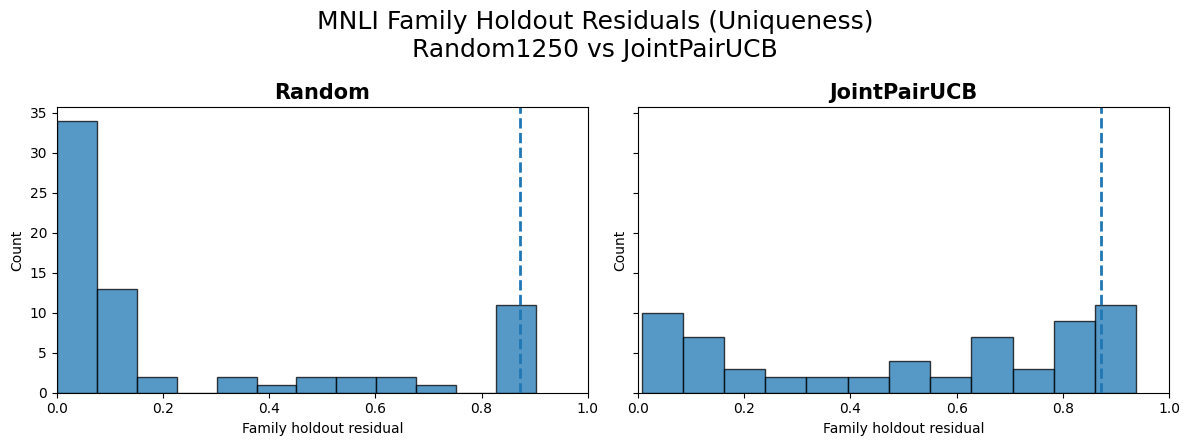

Saved: /home/s243815/project/master-thesis-code-/results/thesis_exp4/mnli/figures/notebook_mnli_random_vs_jointpairucb.png
Pooled Q90: 0.8726


In [8]:
pooled_vals = np.concatenate([random_vals, joint_vals])
q90 = np.quantile(pooled_vals, 0.90)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (name, vals) in zip(
    axes,
    [("Random", random_vals), ("JointPairUCB", joint_vals)]
):
    ax.hist(vals, bins=12, alpha=0.75, edgecolor="black")
    ax.axvline(q90, linestyle="--", linewidth=2)
    ax.set_title(name, fontsize=15, fontweight="bold")
    ax.set_xlabel("Family holdout residual")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1.0)

fig.suptitle(
    "MNLI Family Holdout Residuals (Uniqueness)\nRandom1250 vs JointPairUCB",
    fontsize=18,
)

plt.tight_layout()

out_path = os.path.join(
    OUT_DIR,
    "notebook_mnli_random_vs_jointpairucb.png"
)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
print("Pooled Q90:", round(q90, 4))

In [9]:
tail_rows = []

for name, vals in [
    ("Random", random_vals),
    ("JointPairUCB", joint_vals),
]:
    tail = vals[vals >= q90]
    tail_rows.append({
        "Method": name,
        "Tail Count": len(tail),
        "Tail Mean": np.mean(tail) if len(tail) > 0 else np.nan,
        "Tail Max": np.max(tail) if len(tail) > 0 else np.nan,
    })

tail_summary = pd.DataFrame(tail_rows)
tail_summary.round(4)

,Method,Tail Count,Tail Mean,Tail Max
0,Random,6,0.8877,0.9023
1,JointPairUCB,8,0.8896,0.9382


## 5. Interpretation

The query-matched Random baseline is allowed to use 1200 random queries, matching the approximate total number of model calls used by JointPairUCB with support-set evaluation.

The result shows that Random1200 can occasionally discover high-residual prompt cases. However, the high-residual cases remain sparse and unstable.

In contrast, JointPairUCB produces a higher average residual and a denser high-residual region under family validation. This suggests that the adaptive policy is not only finding isolated prompt spikes, but more stable prompt-family effects.